# Actividad integradora: Segmentación por color

En esta actividad vas a tomar decisiones propias. Ya viste ejemplos guiados; ahora te toca diseñar una estrategia de segmentación, justificarla y revisar tus resultados.

## Consigna general

Podés trabajar de dos maneras:

- con una imagen de ejemplo del repositorio, o
- con `imagen_preprocesada.png` si antes completaste `007 - recuperacion y preprocesamiento de imagenes propias.ipynb`.

La meta no es solo obtener una máscara "linda", sino explicar por qué elegiste esa estrategia y qué límites encontraste.

## Qué se espera que entregues

- una imagen de entrada,
- una o más máscaras de prueba,
- una versión final segmentada,
- una breve justificación de los umbrales elegidos,
- una reflexión sobre errores, ajustes y límites del método.

## Criterios de evaluación

- claridad en la lectura de la imagen,
- justificación de parámetros,
- capacidad para comparar alternativas,
- interpretación crítica del resultado,
- uso claro del lenguaje técnico.


In [1]:
import urllib.request
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def cargar_rgb(ruta):
    imagen_bgr = cv2.imread(str(ruta))
    return cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)


def mostrar_canales(imagen_rgb):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]

    fig, axes = plt.subplots(2, 2, figsize=(10, 9))
    axes[0, 0].imshow(imagen_rgb)
    axes[0, 0].set_title("Imagen original")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(rojo, cmap="gray")
    axes[0, 1].set_title("Canal rojo")
    axes[0, 1].axis("off")

    axes[1, 0].imshow(verde, cmap="gray")
    axes[1, 0].set_title("Canal verde")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(azul, cmap="gray")
    axes[1, 1].set_title("Canal azul")
    axes[1, 1].axis("off")

    plt.tight_layout()
    plt.show()


def mostrar_histogramas(imagen_rgb):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, indice, color, titulo in zip(
        axes,
        [0, 1, 2],
        ["red", "green", "blue"],
        ["Rojo", "Verde", "Azul"],
    ):
        hist, bins = np.histogram(imagen_rgb[:, :, indice].flatten(), bins=256, range=[0, 256])
        ax.plot(bins[:-1], hist, color=color)
        ax.set_title(f"Histograma {titulo}")
        ax.set_xlim(0, 255)
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max):
    rojo = imagen_rgb[:, :, 0]
    verde = imagen_rgb[:, :, 1]
    azul = imagen_rgb[:, :, 2]
    mascara = (
        (rojo >= r_min) & (rojo <= r_max) &
        (verde >= g_min) & (verde <= g_max) &
        (azul >= b_min) & (azul <= b_max)
    )
    return mascara


In [2]:
archivos = {
    "flores": (
        Path("flowers.jpg"),
        "https://www.dropbox.com/s/jetlnfihles3g7k/flowers.jpg?dl=1",
    ),
    "frutos": (
        Path("frutos_rojos.png"),
        "https://www.dropbox.com/s/do6b49d10ty1dyf/frutos_rojos.png?dl=1",
    ),
}

for ruta, url in archivos.values():
    if not ruta.exists():
        urllib.request.urlretrieve(url, ruta)

if Path("imagen_preprocesada.png").exists():
    print("También está disponible: imagen_preprocesada.png")

print("Imágenes listas para la actividad.")


Imágenes listas para la actividad.


## Parte 1. Elegí una imagen y un color objetivo

Si completaste el cuaderno extra de preprocesamiento, te conviene empezar con `imagen_preprocesada.png`. Si no, podés trabajar con `flowers.jpg` o con `frutos_rojos.png`.

Antes de escribir código, anotá qué color querés segmentar y por qué te parece un buen caso para probar.


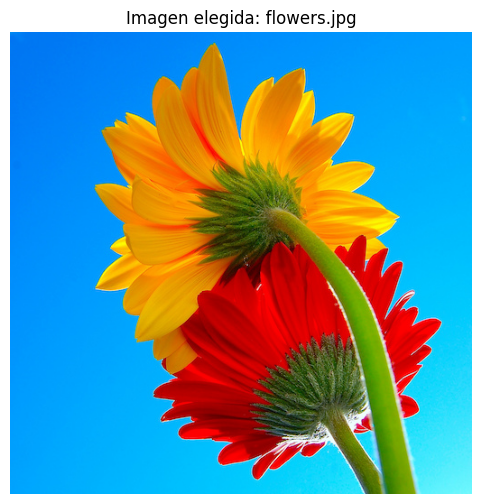

Color objetivo: Voy a segmentar el color azul


In [11]:
# Elegí la imagen con la que vas a trabajar: Elegí la de flowers.jpg porque la que yo utilicé en el notebook 007 me pareció un poco complicada.
nombre_imagen = "flowers.jpg"

imagen_rgb = cargar_rgb(nombre_imagen)

# Escribí en una frase qué color querés segmentar.
color_objetivo = "Voy a segmentar el color azul"

plt.figure(figsize=(6, 6))
plt.imshow(imagen_rgb)
plt.title(f"Imagen elegida: {nombre_imagen}")
plt.axis("off")
plt.show()

print("Color objetivo:", color_objetivo)


## Parte 2. Explorá canales e histogramas

Antes de definir umbrales, mirá la imagen por canales y revisá sus histogramas. La pregunta clave es: ¿qué canal parece más útil para distinguir el color que querés aislar?


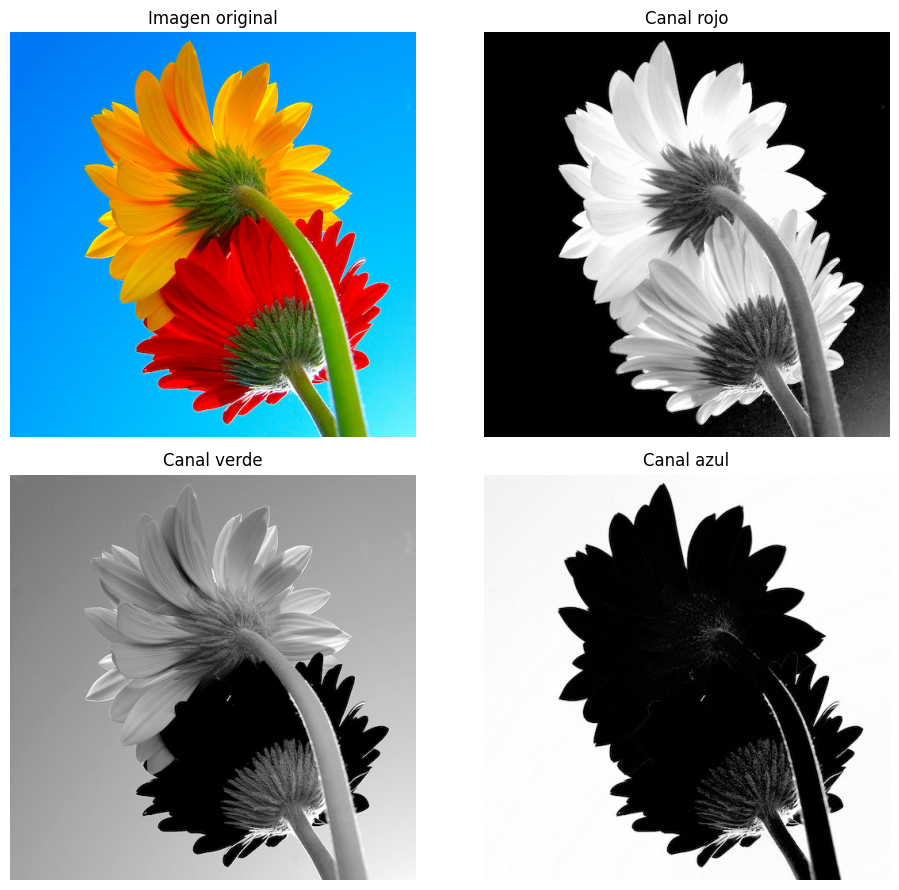

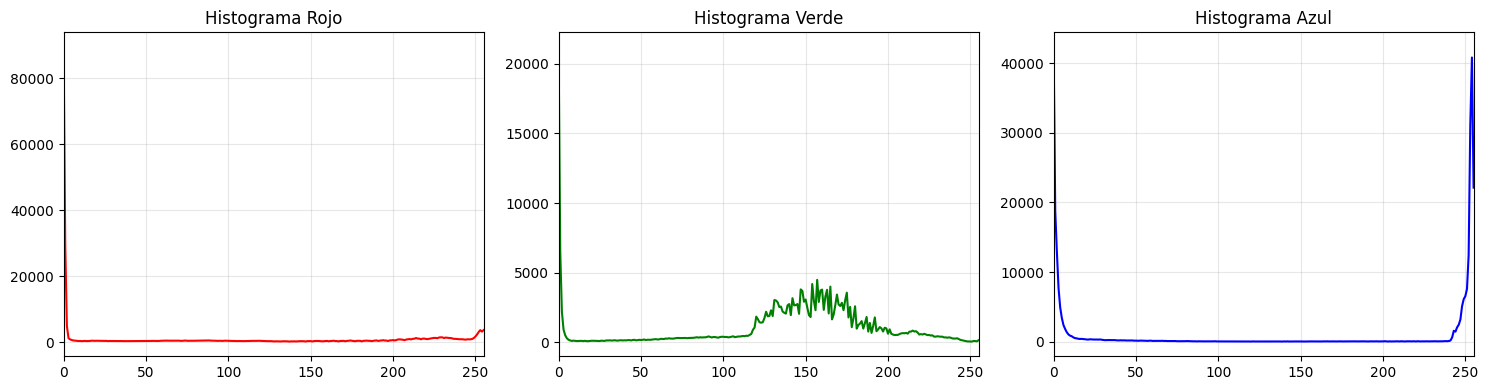

Se trata la imagen por los 3 canales, y en el caso del color azul, conviene el canal azul


In [7]:
mostrar_canales(imagen_rgb)
mostrar_histogramas(imagen_rgb)

# Escribí una observación breve sobre lo que viste.
observacion = "Se trata la imagen por los 3 canales, y en el caso del color azul, conviene el canal azul"
print(observacion)


## Parte 3. Diseñá tu primera estrategia de segmentación

Completá los rangos mínimos y máximos para cada canal. No tienen por qué ser perfectos en el primer intento. La idea es que puedas probar, mirar y corregir.


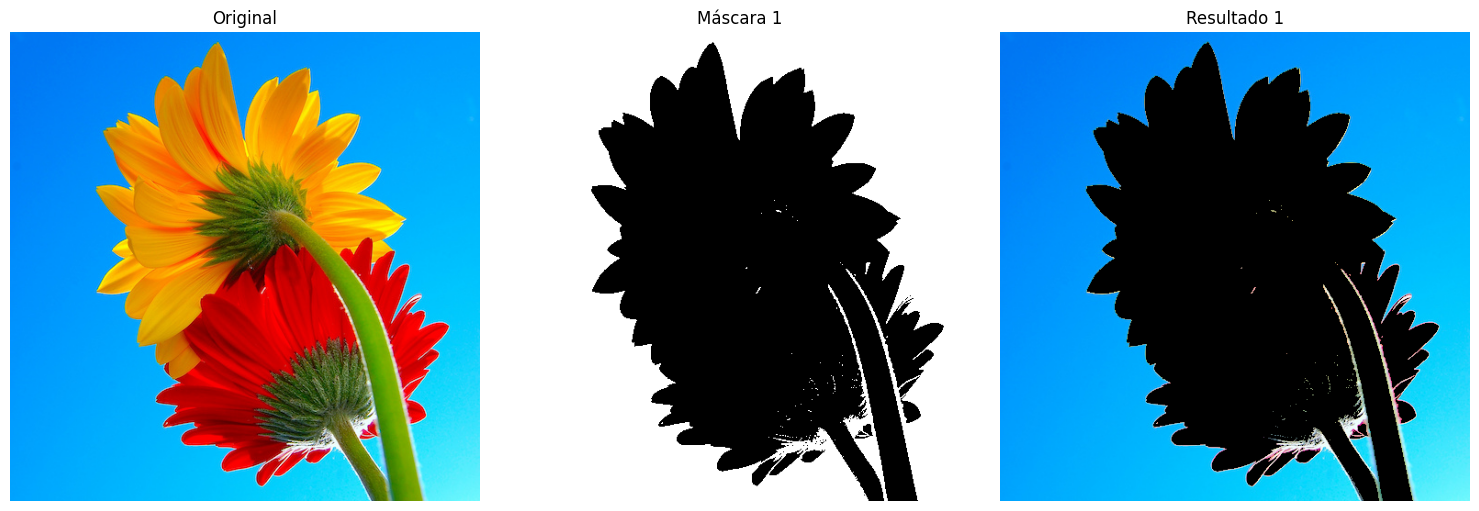

In [8]:
r_min, r_max = 0, 255
g_min, g_max = 0, 255
b_min, b_max = 100, 255

mascara_1 = segmentar_color(imagen_rgb, r_min, r_max, g_min, g_max, b_min, b_max)
resultado_1 = imagen_rgb.copy()
resultado_1[~mascara_1] = 0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(imagen_rgb)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(mascara_1, cmap="gray")
axes[1].set_title("Máscara 1")
axes[1].axis("off")

axes[2].imshow(resultado_1)
axes[2].set_title("Resultado 1")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Parte 4. Revisá y mejorá

Proponé una segunda estrategia. Puede cambiar solo un parámetro o varios. Después compará ambos resultados y explicá cuál conservarías.


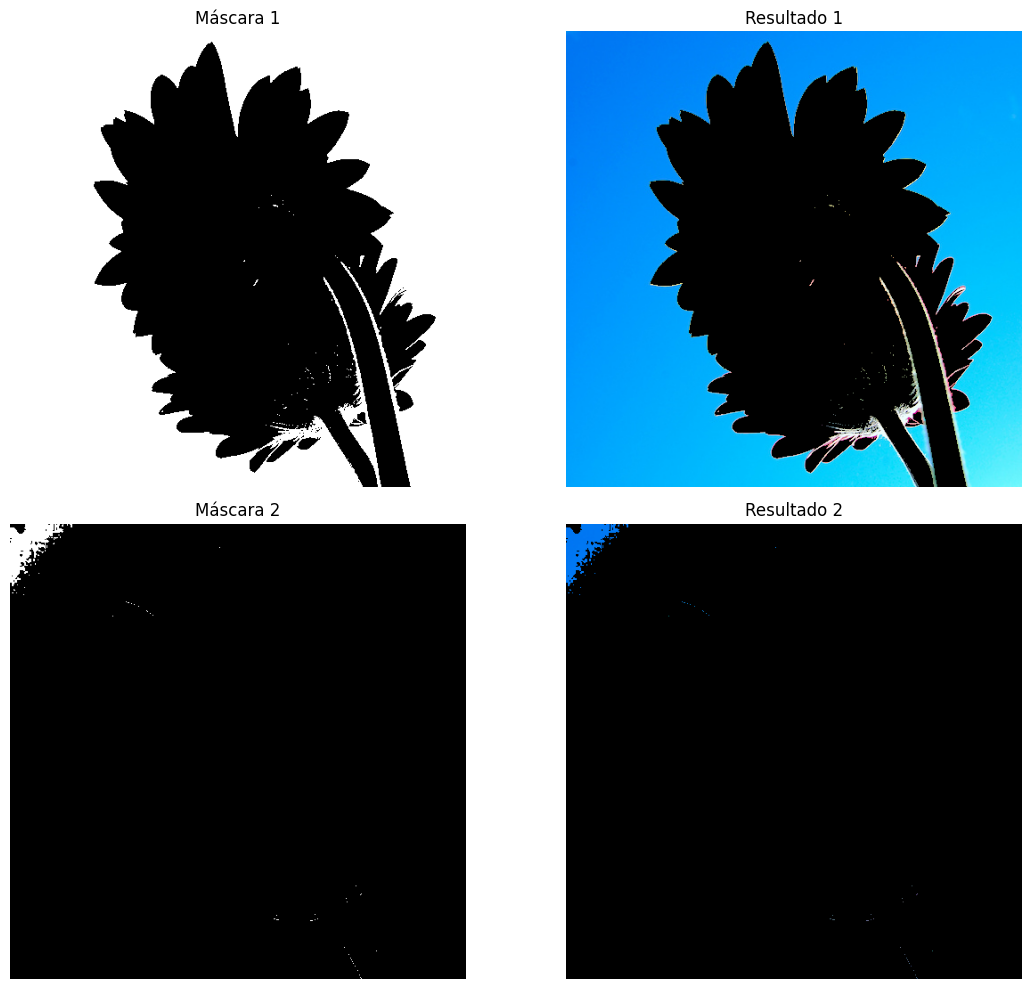

In [9]:
r_min_2, r_max_2 = 0, 120
g_min_2, g_max_2 = 0, 120
b_min_2, b_max_2 = 120, 255

mascara_2 = segmentar_color(imagen_rgb, r_min_2, r_max_2, g_min_2, g_max_2, b_min_2, b_max_2)
resultado_2 = imagen_rgb.copy()
resultado_2[~mascara_2] = 0

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].imshow(mascara_1, cmap="gray")
axes[0, 0].set_title("Máscara 1")
axes[0, 0].axis("off")

axes[0, 1].imshow(resultado_1)
axes[0, 1].set_title("Resultado 1")
axes[0, 1].axis("off")

axes[1, 0].imshow(mascara_2, cmap="gray")
axes[1, 0].set_title("Máscara 2")
axes[1, 0].axis("off")

axes[1, 1].imshow(resultado_2)
axes[1, 1].set_title("Resultado 2")
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Parte 5. Cierre escrito

Respondé con tus palabras:

1. ¿Qué color intentaste segmentar?
El color azul
2. ¿Qué canales te dieron la pista más útil?
El canal azul
3. ¿Qué ajustes hiciste entre la primera y la segunda estrategia? 
En la segunda estrategia se le dio mayor prioridad al canal azul, teniendo un umbral más alto y además se disminuyeron los valores de los canales rojo y verde. Esto permitió aislar mejor las regiones donde predomina el color azul.
4. ¿Qué limitaciones encontraste en este método?
Al limitar los otros colores, causó que parte de la imagen este ahora oscura, y solo una pequeña parte en azul, lo cual indica que este método es muy restrictivo.
5. Si tuvieras más tiempo, ¿qué mejorarías?
Tal vez probaría valores distintos para poder compararlos y analizar si conviene otro tipo de segmentación o si es viable seguir trabajando con el color azul

### Lista de control antes de entregar

- Mostré la imagen original.
- Analicé canales e histogramas.
- Probé al menos dos estrategias.
- Elegí una y la justifiqué.
- Escribí una reflexión final clara.
